## Synthoseis Quick Start Notebook

Synthoseis is an open source, Python-based tool used for generating pseudo-random seismic data. The goal of Synthoseis is to generate realistic seismic data for deep learning training. This notebook will serve as a guide to getting your first Synthoseis model up and running. Future notebooks will discuss seismic outputs, visualizations, and building a custom rock properties model.

### Environment Build

To install the necessary packages, use the `environment.yml` file to create a virtual or conda environment. Please note that the most recent version of Synthoseis has been refactored to work with Python 3.10.

### Imports

Within the main directory of the repo is a script called `main.py`. This is the primary script to run the program. Import `main.py`, along with visualization tools to view the results.

In [2]:
import sys
sys.path.insert(0, '../synthoseis/')
import main as mn 
import numpy as np
import json
import pprint as pp
import matplotlib.pyplot as plt

### Building your first model

The config json file is the method for defining some of the key aspects of your seismic survey including survey size, seismic bandwith, column height range, number of faults, sand thickness ranges, and the presence of geobodies like salt and channels. Please note that setting `include_channels: True` will signifcantly increase compute time and memory consumption. Below is an example config file that can be found in `./config/example.json`.

In [3]:
rock_model = json.load(open('../config/test1.json', 'r'))
pp.pprint(rock_model)

{'bandwidth_high': [20.0, 35.0],
 'bandwidth_low': [3.0, 6.0],
 'bandwidth_ord': 4,
 'basin_floor_fans': False,
 'broadband_qc_volume': False,
 'closure_types': ['simple', 'faulted', 'onlap'],
 'cube_shape': [100, 100, 400],
 'digi': 4,
 'dip_factor_max': 2,
 'extra_qc_plots': True,
 'incident_angles': [7, 15, 24],
 'include_channels': False,
 'include_salt': True,
 'infill_factor': 10,
 'initial_layer_stdev': [7.0, 25.0],
 'max_column_height': [150.0, 150.0],
 'max_number_faults': 6,
 'min_closure_voxels_faulted': 2500,
 'min_closure_voxels_onlap': 500,
 'min_closure_voxels_simple': 500,
 'min_number_faults': 1,
 'model_qc_volumes': True,
 'multiprocess_bp': True,
 'pad_samples': 10,
 'partial_voxels': True,
 'project': 'abc',
 'project_folder': '../data/synthetic_data/test',
 'sand_layer_fraction': {'max': 0.25, 'min': 0.05},
 'sand_layer_thickness': 2,
 'seabed_min_depth': [20, 50],
 'signal_to_noise_ratio_db': [7.5, 12.5, 17.5],
 'thickness_max': 12,
 'thickness_min': 2,
 'variable

### Running the model

Once you've defined the parameters of your seismic data, call the `build_model()` function in `main.py`. This will take the config `.json` file as an input, as well as a `run_id` defined by the user. Users also have the option to use `test_mode`. Test mode can take an integer as an input and returns a smaller seismic volume than defined in the config file. This is great for testing prior to running the full size model.

In [5]:
mn.build_model(user_json='../config/test1.json', run_id=2)

Coherent smiles will be inserted
Salt will be inserted. noise_stretch_factor = 1.29

Model folder: /home/spaceswimmer/Documents/nnseismic/data/synthetic_data/test/seismic__2026.17168789_2
Creating directory: /home/spaceswimmer/Documents/nnseismic/data/synthetic_data/test/seismic__2026.17168789_2
Creating directory: /home/spaceswimmer/Documents/nnseismic/data/synthetic_data/temp/temp_folder__2026.17168789_2

Keyfile created at /home/spaceswimmer/Documents/nnseismic/data/synthetic_data/test/seismic__2026.17168789_2/seismicCube_2026.17168789.key
self.cfg.num_lyr_lut =  8000
onlap_layer_list =  [  6  49 141]
Number of onlapping flags: 3
 ... horizon number for first onlap episode = 6
 ... number of channelFlags: 0
 ... horizon number for first channel episode: 0
	Indices for shallowest point in cube: 46, 83
Building random depth map at base of model
azi, dip, dipping_plane min/mean/max = 178.59039840400925, 0.31138515291477153, 0.00, 0.39, 0.78
current_depth_map min/mean/max = 3937.41, 406

/home/spaceswimmer/Documents/nnseismic/src/../synthoseis/datagenerator/util.py:115: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(20, 15))


Applying simple vertical anti-alias filter


 ... create 3D (pre-faulting) labels for tilting episodes
  ... reminder: tilting events were added at horizons [38, 36, 15, 9]



   ... inside insertOnlap3Dsurface_prefault 
    ... depth_maps min/mean/max, cube_shape = 964.2883267162107 2556.258923147894 4158.667063307935 (100, 100, 4100)
	... k: -15, voxel_count: 10000, sublayer_current_depth_map.mean: 1565.13 
	... k: -14, voxel_count: 20000, sublayer_current_depth_map.mean: 1566.13 
	... k: -13, voxel_count: 30000, sublayer_current_depth_map.mean: 1567.13 
	... k: -12, voxel_count: 40000, sublayer_current_depth_map.mean: 1568.13 
	... k: -11, voxel_count: 50000, sublayer_current_depth_map.mean: 1569.13 
	... k: -10, voxel_count: 60000, sublayer_current_depth_map.mean: 1570.13 
	... k: -9, voxel_count: 70000, sublayer_current_depth_map.mean: 1571.13 
	... k: -8, voxel_count: 80000, sublayer_current_depth_map.mean: 1572.13 
	... k: -7, voxel_count: 90000, sublayer_current_depth_map.mean:

  0%|          | 0/7 [00:00<?, ?it/s]



 ... inserting fault 0 with throw 13.50
   ... fault ellipsoid semi-axes (a, b, c): 563.51, 547.22, 1866.99
   ... fault ellipsoid origin (x, y, z): 74.01, 6.00, -207.57
   ... tilt_pct: 28.64
   ...z for bottom of ellipsoid at depth (samples) = -387535.0
   ...shape of output_cube = (100, 100, 410)
   ...infill_factor, pad_samples = 10, 10
   ...shear_zone_width (samples) = 1.0
   ...gouge_pctile (percent*100) = 45.28245744329348
   .... output_cube.shape = (100, 100, 410)
   .... (np.arange(output_cube.shape[2])*infill_factor).shape = (410,)
    ... Empty intersection between fault and cube, assign d-max at cube lower corner
  ... Ellipsoid larger than cube no fault inserted
      .... set _unfaulted_depths to array with all zeros...


...

Calculating Zoeppritz for 5 angles: 100%|██████████| 100/100 [00:09<00:00, 10.92it/s]



...adding random noise to 5 cubes...
S/N ratio = 12.8738
	...Normalised noise3d for angle 0:	Min: -0.0591, mean: -0.0000, max: 0.0609, std: 0.0054
	S/N ratio = 12.9 dB.
	std_ratio = 4.4024
	data_std = 0.0237
	noise_std = 0.0141
	...Normalised noise3d for angle 7:	Min: -0.0497, mean: -0.0000, max: 0.0462, std: 0.0054
	S/N ratio = 12.9 dB.
	std_ratio = 4.4024
	data_std = 0.0237
	noise_std = 0.0101
	...Normalised noise3d for angle 15:	Min: -0.0502, mean: -0.0000, max: 0.0469, std: 0.0054
	S/N ratio = 12.9 dB.
	std_ratio = 4.4024
	data_std = 0.0237
	noise_std = 0.0101
	...Normalised noise3d for angle 24:	Min: -0.0510, mean: -0.0000, max: 0.0567, std: 0.0054
	S/N ratio = 12.9 dB.
	std_ratio = 4.4024
	data_std = 0.0237
	noise_std = 0.0119
	...Normalised noise3d for angle 45:	Min: -0.0488, mean: -0.0000, max: 0.0543, std: 0.0054
	S/N ratio = 12.9 dB.
	std_ratio = 4.4024
	data_std = 0.0237
	noise_std = 0.0110
Data Min: -0.15, Data Max: 0.46
	... Low Frequency; 3.59 Hz, High Frequency: 20.49 H

/home/spaceswimmer/Documents/nnseismic/src/../synthoseis/datagenerator/Closures.py:3355: RuntimeWarning:

invalid value encountered in divide

/home/spaceswimmer/Documents/nnseismic/src/../synthoseis/datagenerator/Closures.py:3355: RuntimeWarning:

invalid value encountered in divide

/home/spaceswimmer/Documents/nnseismic/src/../synthoseis/datagenerator/Closures.py:3355: RuntimeWarning:

invalid value encountered in divide



layers for closure computation: [ 1  6  7  8 11 14 14 18 19 31 32 35 37 53 54]
Number of HC Closures : 2
Closure voxel count: 4240 - 0.10%
Closure voxel count: (brine) 536 - 0.01%
Closure voxel count: (oil) 1196 - 0.03%
Closure voxel count: (gas) 3044 - 0.07%




...elapsed time is 0:01:34.033442


'/home/spaceswimmer/Documents/nnseismic/data/synthetic_data/test/seismic__2026.17168789_2'

Let's check to see if the test mode seismic data successfully wrote to a temp location. If the data looks correct, turn off test mode and run the full model. A full model of size `(300,300,1250)` will take 30-60 minutes to complete.

In [6]:
seismic = np.load('../data/synthetic_data/test/seismic__2026.17168789_2/seismicCubes_RFC_fullstack_2026.17168789.npy')
print(seismic.shape)

(100, 100, 409)


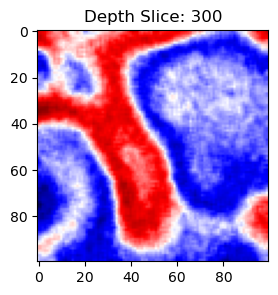

In [7]:
plt.figure(figsize=(3,3))
plt.title('Depth Slice: 300')
plt.imshow(seismic[...,300], cmap=plt.cm.seismic)
plt.show()

In [3]:
from util.filehandler import find_viable_arrays
from util.plotting import plot_3d_array_interactive

In [4]:
gen_data = find_viable_arrays("../data/synthetic_data/test/seismic__2026.17168789_2")
gen_data

Found 82 .npy files
✓ trap_label_2026.17168789.npy: 2 unique values
✓ seismicCubes_RFC_noise_free__24_degrees_2026.17168789.npy: 4090000 unique values
✓ seismicCubes_cumsum_RMO__7_degrees_2026.17168789.npy: 4090000 unique values
✓ faulted_age_2026.17168789.npy: 4079447 unique values
✓ reservoir_label_2026.17168789.npy: 2 unique values
✓ seismicCubes_RFC__15_degrees_normalized_2026.17168789.npy: 4090000 unique values
✓ seismicCubes_cumsum_RMO__15_degrees_normalized_2026.17168789.npy: 4090000 unique values
✓ seismicCubes_cumsum_24_degrees_normalized_augmented_2026.17168789.npy: 4008201 unique values
✓ hc_closures_augmented_2026.17168789.npy: 2 unique values
✓ closure_segments_raw_all_2026.17168789.npy: 2 unique values
✓ depth_maps_gaps_salt.npy: 487891 unique values
✓ seismicCubes_cumsum_RMO__24_degrees_normalized_2026.17168789.npy: 4090000 unique values
✓ seismicCubes_cumsum_noise_free__24_degrees_normalized_2026.17168789.npy: 4090000 unique values
✓ faulted_depth_2026.17168789.npy: 960

['trap_label_2026.17168789.npy',
 'seismicCubes_RFC_noise_free__24_degrees_2026.17168789.npy',
 'seismicCubes_cumsum_RMO__7_degrees_2026.17168789.npy',
 'faulted_age_2026.17168789.npy',
 'reservoir_label_2026.17168789.npy',
 'seismicCubes_RFC__15_degrees_normalized_2026.17168789.npy',
 'seismicCubes_cumsum_RMO__15_degrees_normalized_2026.17168789.npy',
 'seismicCubes_cumsum_24_degrees_normalized_augmented_2026.17168789.npy',
 'hc_closures_augmented_2026.17168789.npy',
 'closure_segments_raw_all_2026.17168789.npy',
 'depth_maps_gaps_salt.npy',
 'seismicCubes_cumsum_RMO__24_degrees_normalized_2026.17168789.npy',
 'seismicCubes_cumsum_noise_free__24_degrees_normalized_2026.17168789.npy',
 'faulted_depth_2026.17168789.npy',
 'seismicCubes_cumsum_RMO__7_degrees_normalized_2026.17168789.npy',
 'sealed_label_2026.17168789.npy',
 'fault_segments_azimuth_2026.17168789.npy',
 'seismicCubes_RFC_noise_free__24_degrees_normalized_2026.17168789.npy',
 'closure_segments_hc_2026.17168789.npy',
 'closu

In [5]:
fold_path = "../data/synthetic_data/test/seismic__2026.17168789_2/"
seismic = np.load(fold_path + gen_data[1])

In [8]:
plot_3d_array_interactive(seismic, axis='x')

interactive(children=(IntSlider(value=0, description='X-index:', max=99), Output()), _dom_classes=('widget-int…